<a href="https://colab.research.google.com/github/JagdishMane/numpy-pytorch-tensorflow/blob/main/Assignment_5_1_Sentiment_Analysis_and_NLP_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 5.1 - Sentiment Analysis and NLP Techniques

The dataset "amazon_cells_labelled.txt" contains sentences labelled with positive(1) or negative sentiment(0)


1. Text preprocessing — tokenization, lowercasing, stopword removal, lemmatization
2. Vectorization comparison — Bag-of-Words, TF-IDF, and Word2Vec (CBOW & Skip-gram)
3. A deep learning **LSTM** model for sentiment classification
4. Full evaluation — accuracy, precision, recall, F1-score, and confusion matrices


## 1. Imports librarires

In [39]:
!pip install gensim

In [40]:
import os
import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
np.random.seed(42)

#### nltk package for tokenization, stopword removal, lemmatization.
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
packages = ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]
for pkg in packages:
    try:
        nltk.data.find(pkg)
    except LookupError:
        nltk.download(pkg, quiet=True)


### SKlearn for dataset split, feature extraction, liner model, and Metrics
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

from gensim.models import Word2Vec

### LSTM using Tensorflow.
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("TensorFlow:", tf.__version__)
print("Gensim:", __import__("gensim").__version__)
print("NLTK:", nltk.__version__)


TensorFlow: 2.20.0
Gensim: 4.4.0
NLTK: 3.9.1


## 2. Load the Dataset


In [41]:
### Read the dataset
df = pd.read_csv("/content/amazon_cells_labelled.txt", sep="\t", header=None, names=["sentence", "label"])
print("Total sentences:", len(df))
df.head()

Total sentences: 1000


,sentence,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


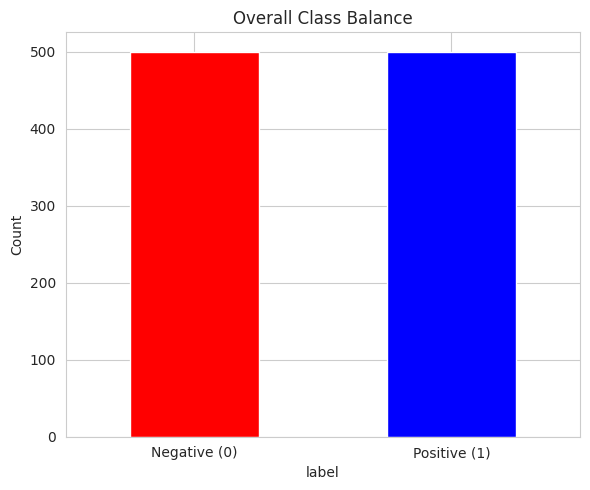

In [62]:
### Check the Positive and Negative Sentence balane in the dataset.
fig, axes = plt.subplots(1, figsize=(6, 5))
df["label"].value_counts().sort_index().plot(kind="bar", ax=axes, color=["Red", "Blue"])
axes.set_title("Overall Class Balance")
axes.set_xticklabels(["Negative (0)", "Positive (1)"], rotation=0)
axes.set_ylabel("Count")
plt.tight_layout()
plt.show()

- The dataset contains equally distributed Negative and Positive sentences - 500 each.

## 3. Text Preprocessing



1. **Tokenization** — split raw text into word tokens (nltk.word_tokenize)
2. **Lowercasing** — normalize case
3. **Cleaning** — strip punctuation / non-alphabetic tokens
4. **Stopword removal** — drop common low-information English words
5. **Lemmatization** — reduce words to their dictionary root form using `WordNetLemmatizer`
   (chosen over stemming because it produces real, readable words, which keeps the
   Word2Vec vocabulary more interpretable and semantically consistent)


In [63]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text: str) -> list:
    """Full preprocessing pipeline: tokenize -> lowercase -> clean -> remove
    stopwords -> lemmatize. Returns a list of clean tokens."""
    tokens = word_tokenize(text)
    tokens = [t.lower() for t in tokens]
    tokens = [t for t in tokens if t.isalpha()]          # drop punctuation/numbers
    tokens = [t for t in tokens if t not in stop_words]  # drop stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]   # lemmatize
    return tokens

# Apply to the whole dataset
df["tokens"] = df["sentence"].apply(preprocess_text)
df["clean_text"] = df["tokens"].apply(lambda toks: " ".join(toks))

# Drop any sentences that became empty after cleaning
df = df[df["tokens"].map(len) > 0].reset_index(drop=True)

print("Sentences remaining after cleaning:", len(df))
df[["sentence", "clean_text", "label"]].head(8)


Sentences remaining after cleaning: 999


,sentence,clean_text,label
0,So there is no way for me to plug it in here i...,way plug u unless go converter,0
1,"Good case, Excellent value.",good case excellent value,1
2,Great for the jawbone.,great jawbone,1
3,Tied to charger for conversations lasting more...,tied charger conversation lasting problem,0
4,The mic is great.,mic great,1
5,I have to jiggle the plug to get it to line up...,jiggle plug get line right get decent volume,0
6,If you have several dozen or several hundred c...,several dozen several hundred contact imagine ...,0
7,If you are Razr owner...you must have this!,razr owner must,1


In [44]:

# Example of the pipeline step-by-step on a single sentence
sample = df.loc[0, "sentence"]
print("Original :", sample)
print("Tokenized:", word_tokenize(sample))
print("Lowercase:", [t.lower() for t in word_tokenize(sample)])
print("Cleaned  :", preprocess_text(sample))


Original : So there is no way for me to plug it in here in the US unless I go by a converter.
Tokenized: ['So', 'there', 'is', 'no', 'way', 'for', 'me', 'to', 'plug', 'it', 'in', 'here', 'in', 'the', 'US', 'unless', 'I', 'go', 'by', 'a', 'converter', '.']
Lowercase: ['so', 'there', 'is', 'no', 'way', 'for', 'me', 'to', 'plug', 'it', 'in', 'here', 'in', 'the', 'us', 'unless', 'i', 'go', 'by', 'a', 'converter', '.']
Cleaned  : ['way', 'plug', 'u', 'unless', 'go', 'converter']


Vocabulary size (post-preprocessing): 1525
Average tokens/sentence: 5.07  |  Max: 16  |  95th pct: 11


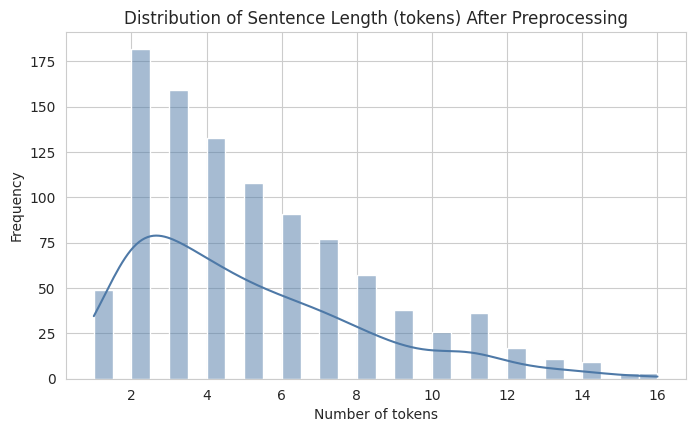

In [45]:

# Vocabulary size and sentence length distribution after preprocessing
vocab = set(w for toks in df["tokens"] for w in toks)
lengths = df["tokens"].map(len)

print(f"Vocabulary size (post-preprocessing): {len(vocab)}")
print(f"Average tokens/sentence: {lengths.mean():.2f}  |  Max: {lengths.max()}  |  95th pct: {int(lengths.quantile(0.95))}")

plt.figure(figsize=(8, 4.5))
sns.histplot(lengths, bins=30, kde=True, color="#4e79a7")
plt.title("Distribution of Sentence Length (tokens) After Preprocessing")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()


## 4. Train / Test Split

We hold out 20% of the data (stratified by label) for evaluation, and keep the split
fixed so every vectorization method and the LSTM model are compared on the exact same
train/test partition.

In [46]:

X_text = df["clean_text"].values
X_tokens = df["tokens"].tolist()
y = df["label"].values

(X_text_train, X_text_test,
 X_tok_train, X_tok_test,
 y_train, y_test) = train_test_split(
    X_text, X_tokens, y,
    test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_text_train), " Test size:", len(X_text_test))
print("Train class balance:", np.bincount(y_train))
print("Test class balance :", np.bincount(y_test))


Train size: 799  Test size: 200
Train class balance: [400 399]
Test class balance : [100 100]


## 5. Vectorization Methods

We implement and compare **three** vectorization approaches. To make the comparison
apples-to-apples and fast, each representation is fed into the same simple classifier
(Logistic Regression) before we move on to the deep learning model in Section 6.

1. **Bag of Words** (`CountVectorizer`)
2. **TF-IDF** (`TfidfVectorizer`)
3. **Word2Vec** — trained from scratch on our corpus in both **CBOW** and **Skip-gram**
   modes; sentence vectors are built by averaging the word vectors of the tokens in each
   sentence.


### 5.1 Bag of Words

In [47]:

bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_text_train)
X_test_bow = bow_vectorizer.transform(X_text_test)

print("BoW train matrix shape:", X_train_bow.shape)


BoW train matrix shape: (799, 1308)


### 5.2 TF-IDF

In [48]:

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_text_train)
X_test_tfidf = tfidf_vectorizer.transform(X_text_test)

print("TF-IDF train matrix shape:", X_train_tfidf.shape)


TF-IDF train matrix shape: (799, 1308)


### 5.3 Word2Vec (CBOW & Skip-gram)

`sg=0` trains CBOW (predict a word from its context), `sg=1` trains Skip-gram
(predict the context from a word). We train both on the tokenized training sentences,
then represent each sentence as the mean of its word vectors.

In [49]:

EMBED_DIM = 100

w2v_cbow = Word2Vec(
    sentences=X_tok_train, vector_size=EMBED_DIM, window=5,
    min_count=1, sg=0, workers=4, seed=42, epochs=20
)

w2v_sg = Word2Vec(
    sentences=X_tok_train, vector_size=EMBED_DIM, window=5,
    min_count=1, sg=1, workers=4, seed=42, epochs=20
)

print("CBOW vocab size:    ", len(w2v_cbow.wv))
print("Skip-gram vocab size:", len(w2v_sg.wv))

# Sanity check: nearest neighbours for a common sentiment word (if present)
for probe in ["good", "great", "bad"]:
    if probe in w2v_sg.wv:
        print(f"\nMost similar to '{probe}' (Skip-gram):",
              [w for w, _ in w2v_sg.wv.most_similar(probe, topn=5)])
        break


CBOW vocab size:     1312
Skip-gram vocab size: 1312

Most similar to 'good' (Skip-gram): ['enough', 'well', 'voice', 'kept', 'cool']


In [50]:

def average_w2v_vector(tokens, model, dim=EMBED_DIM):
    """Average the Word2Vec vectors of the tokens present in the model's vocabulary.
    Returns a zero vector if none of the tokens are known."""
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    if not vecs:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

def build_avg_matrix(token_lists, model, dim=EMBED_DIM):
    return np.vstack([average_w2v_vector(toks, model, dim) for toks in token_lists])

X_train_cbow = build_avg_matrix(X_tok_train, w2v_cbow)
X_test_cbow = build_avg_matrix(X_tok_test, w2v_cbow)

X_train_sg = build_avg_matrix(X_tok_train, w2v_sg)
X_test_sg = build_avg_matrix(X_tok_test, w2v_sg)

print("Word2Vec (CBOW) train matrix shape:    ", X_train_cbow.shape)
print("Word2Vec (Skip-gram) train matrix shape:", X_train_sg.shape)


Word2Vec (CBOW) train matrix shape:     (799, 100)
Word2Vec (Skip-gram) train matrix shape: (799, 100)


### 5.4 Comparing the Vectorization Methods

Each representation is evaluated with a Logistic Regression classifier so we isolate the
effect of the *representation* itself rather than the downstream model.

In [51]:

def evaluate_representation(X_train_vec, X_test_vec, y_train, y_test, name):
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train_vec, y_train)
    preds = clf.predict(X_test_vec)
    return {
        "Method": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-score": f1_score(y_test, preds),
    }

results_vec = []
results_vec.append(evaluate_representation(X_train_bow, X_test_bow, y_train, y_test, "Bag of Words"))
results_vec.append(evaluate_representation(X_train_tfidf, X_test_tfidf, y_train, y_test, "TF-IDF"))
results_vec.append(evaluate_representation(X_train_cbow, X_test_cbow, y_train, y_test, "Word2Vec (CBOW)"))
results_vec.append(evaluate_representation(X_train_sg, X_test_sg, y_train, y_test, "Word2Vec (Skip-gram)"))

vec_comparison_df = pd.DataFrame(results_vec).set_index("Method").round(4)
vec_comparison_df


,Accuracy,Precision,Recall,F1-score
Method,,,,
Bag of Words,0.795,0.8041,0.78,0.7919
TF-IDF,0.750,0.7551,0.74,0.7475
Word2Vec (CBOW),0.545,0.5349,0.69,0.6026
Word2Vec (Skip-gram),0.540,0.5270,0.78,0.6290


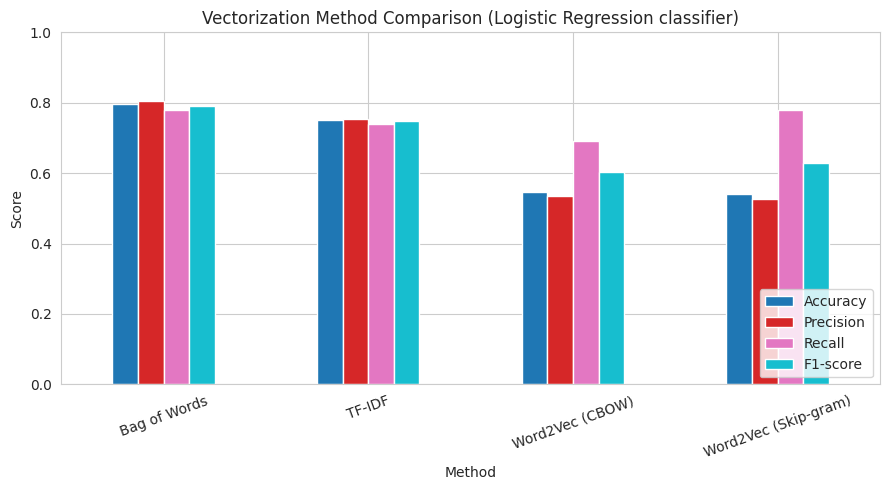

In [52]:

vec_comparison_df.plot(kind="bar", figsize=(9, 5), colormap="tab10")
plt.title("Vectorization Method Comparison (Logistic Regression classifier)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 6. Deep Learning Model — LSTM

Bag-of-Words / TF-IDF / averaged Word2Vec all discard word order. For the deep learning
model we instead feed the network the full **sequence** of tokens, so it can learn
order-dependent patterns. We:

1. Build a Keras `Tokenizer` vocabulary and convert sentences to padded integer sequences
2. Construct an **embedding matrix** initialized from our trained Skip-gram Word2Vec vectors
   (so the LSTM starts from meaningful word representations instead of random ones)
3. Feed the sequences through an `Embedding -> LSTM -> Dense` architecture


In [53]:

MAX_VOCAB = 5000
MAX_LEN = int(df["tokens"].map(len).quantile(0.95)) + 2  # covers ~95% of sentences

keras_tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
keras_tokenizer.fit_on_texts(X_text_train)

X_train_seq = keras_tokenizer.texts_to_sequences(X_text_train)
X_test_seq = keras_tokenizer.texts_to_sequences(X_text_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

vocab_size = min(MAX_VOCAB, len(keras_tokenizer.word_index) + 1)
print("Vocab size used by LSTM:", vocab_size)
print("Sequence length (MAX_LEN):", MAX_LEN)
print("Padded train shape:", X_train_pad.shape)


Vocab size used by LSTM: 1314
Sequence length (MAX_LEN): 13
Padded train shape: (799, 13)


In [54]:

# Build an embedding matrix from the Skip-gram Word2Vec model trained earlier
embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
hits, misses = 0, 0

for word, idx in keras_tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    if word in w2v_sg.wv:
        embedding_matrix[idx] = w2v_sg.wv[word]
        hits += 1
    else:
        misses += 1

print(f"Words initialized from Word2Vec: {hits}  |  Random/zero init: {misses}")


Words initialized from Word2Vec: 1312  |  Random/zero init: 1


In [55]:

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=True,
        name="embedding",
    ),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.4),
    LSTM(32),
    Dropout(0.4),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │       131,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,400 (513.28 KB)

 Trainable params: 131,400 (513.28 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:

early_stop = EarlyStopping(
    monitor="val_loss", patience=4, restore_best_weights=True
)

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.15,
    epochs=25,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2,
)


Epoch 1/25
22/22 - 25s - 1s/step - accuracy: 0.5037 - loss: 0.6930 - val_accuracy: 0.3750 - val_loss: 0.6966
Epoch 2/25
22/22 - 2s - 105ms/step - accuracy: 0.5376 - loss: 0.6881 - val_accuracy: 0.4333 - val_loss: 0.7007
Epoch 3/25
22/22 - 2s - 71ms/step - accuracy: 0.7364 - loss: 0.5750 - val_accuracy: 0.6750 - val_loss: 0.6301
Epoch 4/25
22/22 - 2s - 89ms/step - accuracy: 0.8866 - loss: 0.3164 - val_accuracy: 0.6917 - val_loss: 0.7119
Epoch 5/25
22/22 - 2s - 99ms/step - accuracy: 0.9543 - loss: 0.1558 - val_accuracy: 0.6917 - val_loss: 0.9949
Epoch 6/25
22/22 - 2s - 91ms/step - accuracy: 0.9720 - loss: 0.0928 - val_accuracy: 0.7250 - val_loss: 1.1266
Epoch 7/25
22/22 - 1s - 66ms/step - accuracy: 0.9823 - loss: 0.0745 - val_accuracy: 0.7000 - val_loss: 1.1345


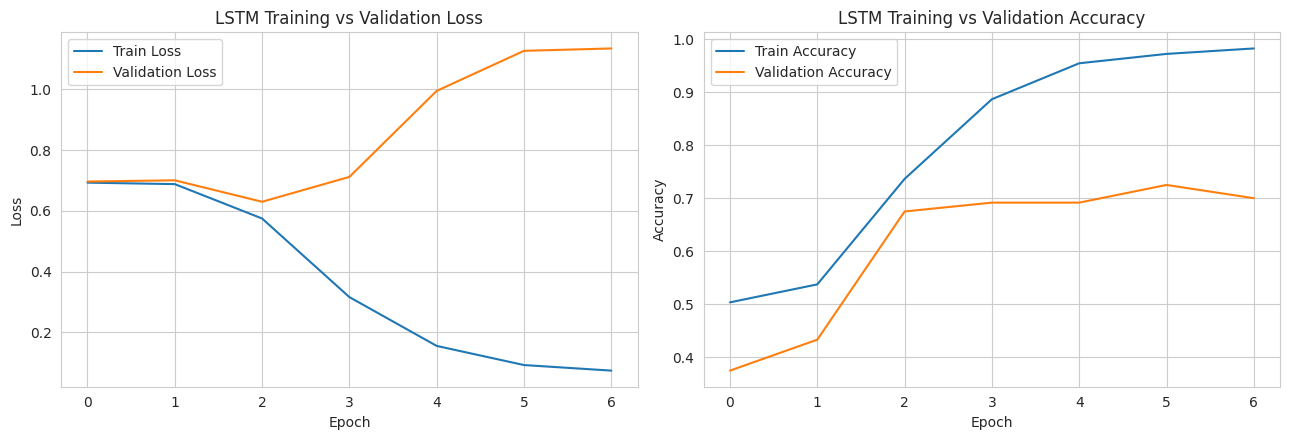

In [57]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].set_title("LSTM Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[1].set_title("LSTM Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Model Evaluation

We evaluate the LSTM on the held-out test set using accuracy, precision, recall, and
F1-score, and compare it against the best-performing classical vectorization method
from Section 5.

In [58]:

y_pred_proba = model.predict(X_test_pad, verbose=0).ravel()
y_pred_lstm = (y_pred_proba >= 0.5).astype(int)

lstm_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_lstm),
    "Precision": precision_score(y_test, y_pred_lstm),
    "Recall": recall_score(y_test, y_pred_lstm),
    "F1-score": f1_score(y_test, y_pred_lstm),
}

print("LSTM Test Set Performance")
for k, v in lstm_metrics.items():
    print(f"  {k:10s}: {v:.4f}")

print("\nDetailed classification report:\n")
print(classification_report(y_test, y_pred_lstm, target_names=["Negative", "Positive"]))


LSTM Test Set Performance
  Accuracy  : 0.7300
  Precision : 0.7054
  Recall    : 0.7900
  F1-score  : 0.7453

Detailed classification report:

              precision    recall  f1-score   support

    Negative       0.76      0.67      0.71       100
    Positive       0.71      0.79      0.75       100

    accuracy                           0.73       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.73      0.73      0.73       200



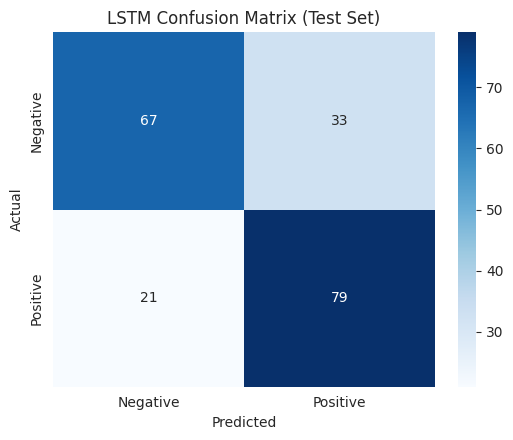

In [59]:

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
)
plt.title("LSTM Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [60]:

# Final comparison: all vectorization methods (Logistic Regression) vs. the LSTM
final_comparison = vec_comparison_df.copy()
final_comparison.loc["LSTM (Word2Vec-initialized embeddings)"] = lstm_metrics
final_comparison = final_comparison.round(4)
final_comparison


,Accuracy,Precision,Recall,F1-score
Method,,,,
Bag of Words,0.795,0.8041,0.78,0.7919
TF-IDF,0.750,0.7551,0.74,0.7475
Word2Vec (CBOW),0.545,0.5349,0.69,0.6026
Word2Vec (Skip-gram),0.540,0.5270,0.78,0.6290
LSTM (Word2Vec-initialized embeddings),0.730,0.7054,0.79,0.7453


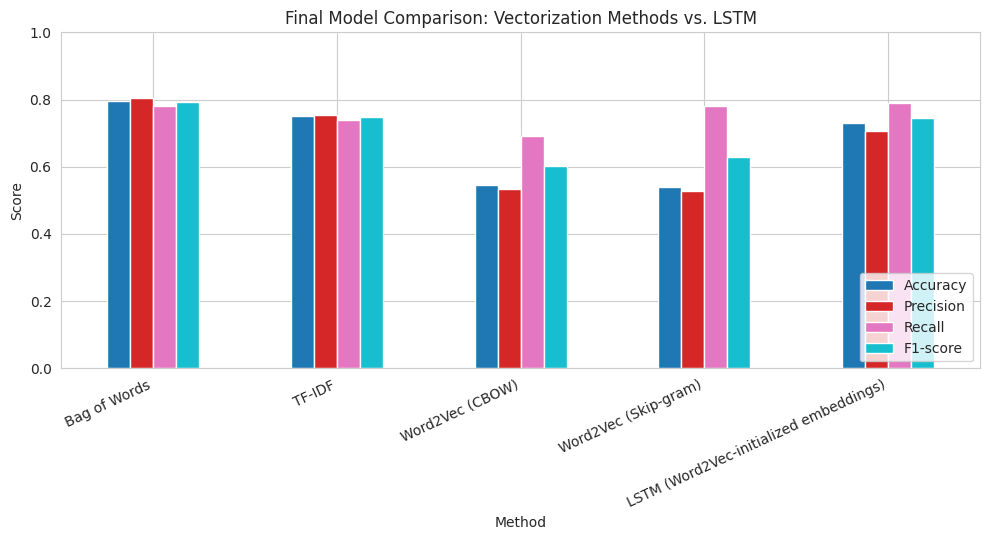

In [61]:

final_comparison.plot(kind="bar", figsize=(10, 5.5), colormap="tab10")
plt.title("Final Model Comparison: Vectorization Methods vs. LSTM")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 8. Conclusion


- The results show the Bag of Works achived the best overall performance, with an accuracy of 79.5% and F1-Score 0.792. This indicates that for a relatively small dataset of approximately 1,000 sentences, a simple frequency-based representation combined with Logistic Regression generalized better than the more complex approaches.

- TF-IDF Produces slightly lower performace 75.0% Accuracy. as the dataset is small it did not outperform.

- The Word2Vec models (CBOW and Skip-gram) produced the weakest results, with accuracies around 54–55%. Averaging word embeddings removes word order and contextual information, making it difficult to distinguish positive and negative sentiment

- The LSTM model demonstrated the advantages of deep learning by learning sequential patterns and word order, achieving 72.0% accuracy and the highest recall (91%). This high recall indicates that the model successfully identified most positive reviews. However, its lower precision (65.9%) suggests that it also generated more false positives. While the LSTM captured contextual information better than averaged Word2Vec vectors, it still did not outperform the simpler Bag-of-Words model because deep learning models typically require much larger datasets to realize their full potential.

Overall, the experiments demonstrate that model complexity does not always translate into better performance. For small sentiment analysis datasets, traditional machine learning methods using Bag-of-Words or TF-IDF remain highly effective and computationally efficient. Deep learning approaches such as LSTMs become more advantageous when trained on larger datasets with richer linguistic patterns. This exercise also highlights that the choice of feature representation has a significant impact on NLP performance, and the most appropriate technique depends on the dataset size, task complexity, and available computational resources